<a href="https://colab.research.google.com/github/yanhyee/SIT-UofG-QC-Assignment/blob/main/BB84-Plain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 71.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=833fe01d2e4ade0f3a67c7fb4ca248beff464707677da61a8ebaff08d98dce93
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.



# Step 1: Helper functions

The assignment says that random choices should be generated by measuring a quantum state such as $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$, rather than using a standard Python random number generator. The function `quantum_random_bit()` does exactly that.

In [3]:
# Helper functions used by both versions of BB84
# IMPORTANT: Random choices are generated by measuring |+> = (|0> + |1>) / sqrt(2).
# This follows the assignment requirement not to use Python's random number generator.

backend = BasicSimulator()

def quantum_random_bit():
    """Return one random bit by preparing |+> and measuring it."""
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.measure(0, 0)
    compiled = transpile(qc, backend)
    result = backend.run(compiled, shots=1).result()
    counts = result.get_counts()
    return int(next(iter(counts)))


def quantum_random_bits(n):
    """Return n random bits generated quantum mechanically."""
    return [quantum_random_bit() for _ in range(n)]


def basis_name(basis):
    """0 means computational/rectilinear basis (+); 1 means diagonal basis (x)."""
    return '+' if basis == 0 else 'x'


def bit_list_to_string(bits):
    return ''.join(str(bit) for bit in bits)


def encode_qubit(bit, basis):
    """
    Alice encodes one classical bit into one qubit.

    basis = 0: computational basis
        bit 0 -> |0>
        bit 1 -> |1>

    basis = 1: diagonal basis
        bit 0 -> |+>
        bit 1 -> |->
    """
    qc = QuantumCircuit(1, 1)

    if bit == 1:
        qc.x(0)

    if basis == 1:
        qc.h(0)

    return qc


def measure_encoded_qubit(encoded_circuit, measurement_basis):
    """
    Measure a qubit in the chosen basis.

    If measurement_basis = 0, measure in computational basis.
    If measurement_basis = 1, apply H first so diagonal-basis information becomes measurable.
    """
    qc = encoded_circuit.copy()

    if measurement_basis == 1:
        qc.h(0)

    qc.measure(0, 0)
    compiled = transpile(qc, backend)
    result = backend.run(compiled, shots=1).result()
    counts = result.get_counts()
    return int(next(iter(counts)))


def sift_key(bits, alice_bases, bob_bases, bob_results):
    """
    Keep only the positions where Alice and Bob used the same basis.
    These positions form the sifted key.
    """
    matching_positions = []
    alice_key = []
    bob_key = []

    for i in range(len(bits)):
        if alice_bases[i] == bob_bases[i]:
            matching_positions.append(i)
            alice_key.append(bits[i])
            bob_key.append(bob_results[i])

    return matching_positions, alice_key, bob_key


def compare_sample(alice_key, bob_key, sample_size):
    """
    Compare the first sample_size bits of the sifted key to estimate the error rate.
    In a real protocol, these sample bits would be revealed publicly and then discarded.
    """
    sample_size = min(sample_size, len(alice_key), len(bob_key))

    if sample_size == 0:
        return 0, 0.0

    mismatches = 0
    for i in range(sample_size):
        if alice_key[i] != bob_key[i]:
            mismatches += 1

    error_rate = mismatches / sample_size
    return mismatches, error_rate


def print_protocol_table(alice_bits, alice_bases, bob_bases, bob_results, matching_positions):
    """Display the main BB84 values in a compact table."""
    print('i  Alice bit  Alice basis  Bob basis  Bob result  Keep?')
    print('-' * 58)
    for i in range(len(alice_bits)):
        keep = 'yes' if i in matching_positions else 'no'
        print(f'{i:2d}     {alice_bits[i]}          {basis_name(alice_bases[i])}           {basis_name(bob_bases[i])}          {bob_results[i]}        {keep}')


## Step 2: Alice chooses random bits and random bases

Alice needs two random strings: the raw key bits and the bases used to encode those bits.

In [4]:
# Parameters for the demonstration
N = 40              # Number of qubits sent by Alice
SAMPLE_SIZE = 10    # Number of sifted-key bits revealed to check for errors
THRESHOLD = 0.20    # If error rate is above this, report possible attack/noise

# Alice generates random bits and random bases using quantum randomness
alice_bits = quantum_random_bits(N)
alice_bases = quantum_random_bits(N)

print('Alice raw bits:  ', bit_list_to_string(alice_bits))
print('Alice bases:     ', ''.join(basis_name(b) for b in alice_bases))

Alice raw bits:   1110001010001111001011100100100100001101
Alice bases:      xxxx+++x++xx++x+x+xx+x+++x+x++xxx+xx+++x


## Step 3: Alice encodes the qubits

For each bit, Alice prepares a qubit in either the computational basis `+` or diagonal basis `x`.

Alice encoded and sent 40 qubits.
Example encoded qubit circuit:


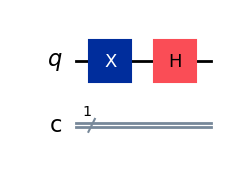

In [5]:
encoded_qubits = []

for bit, basis in zip(alice_bits, alice_bases):
    encoded_qubits.append(encode_qubit(bit, basis))

print(f'Alice encoded and sent {len(encoded_qubits)} qubits.')

# Draw one example qubit circuit
print('Example encoded qubit circuit:')
encoded_qubits[0].draw('mpl')

## Step 4: Bob chooses random bases and measures

Bob does not know Alice's bases, so he randomly chooses a basis for each qubit.

In [6]:
bob_bases = quantum_random_bits(N)
bob_results = []

for qubit, basis in zip(encoded_qubits, bob_bases):
    bob_results.append(measure_encoded_qubit(qubit, basis))

print('Bob bases:       ', ''.join(basis_name(b) for b in bob_bases))
print('Bob results:     ', bit_list_to_string(bob_results))

Bob bases:        ++x+x+++++xx+xxx++xx+x+xx++xx+++x+++xxx+
Bob results:      1111001110001110001011111000000100001110


## Step 5: Public basis comparison and key sifting

Alice and Bob publicly compare only their bases, not their actual bit values. They keep only the positions where their bases match.

In [7]:
matching_positions, alice_key, bob_key = sift_key(
    alice_bits,
    alice_bases,
    bob_bases,
    bob_results
)

print_protocol_table(alice_bits, alice_bases, bob_bases, bob_results, matching_positions)

print('\nMatching positions:', matching_positions)
print('Alice sifted key:  ', bit_list_to_string(alice_key))
print('Bob sifted key:    ', bit_list_to_string(bob_key))
print('Sifted key length: ', len(alice_key))

i  Alice bit  Alice basis  Bob basis  Bob result  Keep?
----------------------------------------------------------
 0     1          x           +          1        no
 1     1          x           +          1        no
 2     1          x           x          1        yes
 3     0          x           +          1        no
 4     0          +           x          0        no
 5     0          +           +          0        yes
 6     1          +           +          1        yes
 7     0          x           +          1        no
 8     1          +           +          1        yes
 9     0          +           +          0        yes
10     0          x           x          0        yes
11     0          x           x          0        yes
12     1          +           +          1        yes
13     1          +           x          1        no
14     1          x           x          1        yes
15     1          +           x          0        no
16     0          x         

## Step 6: Error-rate check

Alice and Bob reveal a small sample of their sifted key. Without an attacker, the error rate should usually be very low or zero in this ideal simulation.

In [8]:
mismatches, error_rate = compare_sample(alice_key, bob_key, SAMPLE_SIZE)

print(f'Sample size checked: {min(SAMPLE_SIZE, len(alice_key))}')
print(f'Mismatches found:    {mismatches}')
print(f'Estimated error rate: {error_rate:.2%}')

if error_rate > THRESHOLD:
    print('Result: Possible attack/noise detected. Do not use this key.')
else:
    print('Result: No attack detected. Alice and Bob can use the remaining key bits.')

# In a real BB84 protocol, the sample bits are discarded after being revealed.
final_alice_key = alice_key[min(SAMPLE_SIZE, len(alice_key)):]
final_bob_key = bob_key[min(SAMPLE_SIZE, len(bob_key)):]

print('\nFinal Alice key after discarding sample:', bit_list_to_string(final_alice_key))
print('Final Bob key after discarding sample:  ', bit_list_to_string(final_bob_key))

Sample size checked: 10
Mismatches found:    0
Estimated error rate: 0.00%
Result: No attack detected. Alice and Bob can use the remaining key bits.

Final Alice key after discarding sample: 1011100000
Final Bob key after discarding sample:   1011100000


## Conclusion

In the no-attacker version, Alice and Bob should obtain the same sifted key whenever their bases match. Any differences would come only from measurement randomness when the wrong basis was used, but those positions are removed during sifting.